
---

# ⚡ **`Handling Outliers with Python in Machine Learning for Data Science`** 📊

**Outliers** are data points that deviate significantly from the majority of data. While some outliers carry valuable information (e.g., fraud detection), others can distort **statistical analyses** and **machine learning (ML) models**, leading to **poor predictions**.

In this guide, you'll learn:  
1. ✅ **What Are Outliers?**  
2. 🔍 **How to Detect Outliers**  
3. 🛠️ **Techniques to Handle Outliers**  
4. 📊 **Visualizing Outliers**  
5. 🤖 **Outlier Detection Using ML Algorithms**  

---

## ✅ **1. What Are Outliers?**  

An **outlier** is a data point that lies far away from other points in the dataset.  

### 💡 **Why Handle Outliers?**  
- ❌ **Bias in Model Training:** Outliers can skew ML algorithms, especially regression-based models.  
- ❌ **Distorted Summary Statistics:** Mean, standard deviation, and correlation can be heavily affected.  
- ✅ **Better Generalization:** Handling outliers improves model accuracy and robustness.  

---

## 🔍 **2. Detecting Outliers**  

### 📁 **Sample Dataset:**


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a sample dataset
data = {'Age': [25, 30, 29, 35, 28, 22, 26, 120, 27, 23, 29], 
        'Salary': [50000, 52000, 48000, 51000, 49000, 47000, 50000, 1000000, 52000, 48000, 51000]}

df = pd.DataFrame(data)
print(df)

    Age   Salary
0    25    50000
1    30    52000
2    29    48000
3    35    51000
4    28    49000
5    22    47000
6    26    50000
7   120  1000000
8    27    52000
9    23    48000
10   29    51000



---

### 📏 **2.1 Detecting Outliers Using Descriptive Statistics:**


In [3]:

# Summary statistics
print(df.describe())


              Age          Salary
count   11.000000       11.000000
mean    35.818182   136181.818182
std     28.145402   286500.896397
min     22.000000    47000.000000
25%     25.500000    48500.000000
50%     28.000000    50000.000000
75%     29.500000    51500.000000
max    120.000000  1000000.000000




- **Look for:**  
  - **Extreme values** in min/max.  
  - **High standard deviation** indicating data spread.  

---

### 📊 **2.2 Visualizing Outliers:**

#### ✅ **Boxplot (IQR Method):**

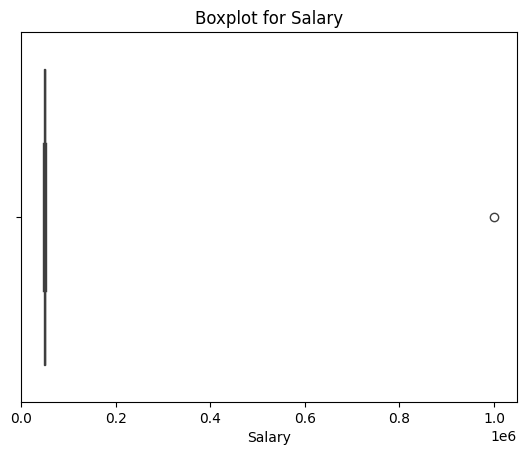

In [4]:

# Boxplot for Salary
sns.boxplot(x=df['Salary'])
plt.title("Boxplot for Salary")
plt.show()



**🔎 Interpretation:**  
- Points outside the "whiskers" are considered potential outliers.  

---

#### ✅ **Scatter Plot:**

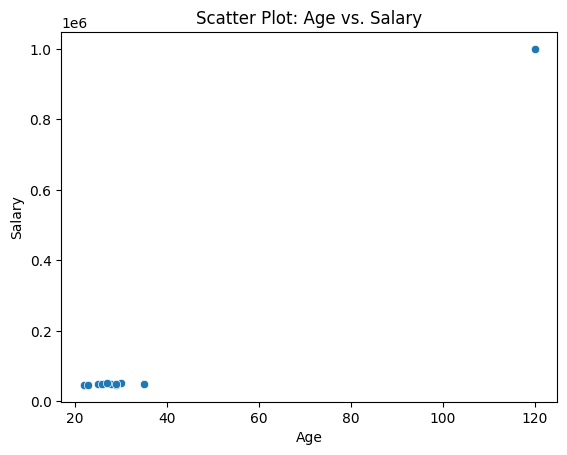

In [5]:

# Scatter plot for Age vs. Salary
sns.scatterplot(x='Age', y='Salary', data=df)
plt.title("Scatter Plot: Age vs. Salary")
plt.show()



**🔎 Interpretation:**  
- Look for points far away from the general cluster.

---

### 📊 **2.3 Z-Score Method:**  
Outliers typically have a **Z-score > 3** or **< -3**.


In [6]:

from scipy import stats

# Calculate Z-scores
df['Salary_Zscore'] = stats.zscore(df['Salary'])

# Identify outliers
outliers = df[df['Salary_Zscore'].abs() > 3]
print("Outliers:\n", outliers)


Outliers:
    Age   Salary  Salary_Zscore
7  120  1000000       3.162224



---

### 📊 **2.4 Interquartile Range (IQR) Method:**  
A robust technique that isn’t affected by extreme values.

In [7]:

# IQR Calculation
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
iqr_outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
print("IQR Outliers:\n", iqr_outliers)


IQR Outliers:
    Age   Salary  Salary_Zscore
7  120  1000000       3.162224



---

## 🛠️ **3. Handling Outliers**  

### ⚡ **3.1 Removing Outliers:**  
**When to use:** If outliers are due to data entry errors or irrelevant to analysis.

In [8]:

# Remove outliers based on IQR bounds
df_cleaned = df[(df['Salary'] >= lower_bound) & (df['Salary'] <= upper_bound)]
print(df_cleaned)


    Age  Salary  Salary_Zscore
0    25   50000      -0.315490
1    30   52000      -0.308169
2    29   48000      -0.322812
3    35   51000      -0.311830
4    28   49000      -0.319151
5    22   47000      -0.326473
6    26   50000      -0.315490
8    27   52000      -0.308169
9    23   48000      -0.322812
10   29   51000      -0.311830



---

### ⚡ **3.2 Capping or Flooring (Winsorization):**  
Limit extreme values to a specific percentile.


In [9]:

from scipy.stats.mstats import winsorize

# Apply Winsorization on Salary
df['Salary_Winsorized'] = winsorize(df['Salary'], limits=[0.05, 0.05])
print(df[['Salary', 'Salary_Winsorized']])


     Salary  Salary_Winsorized
0     50000              50000
1     52000              52000
2     48000              48000
3     51000              51000
4     49000              49000
5     47000              47000
6     50000              50000
7   1000000            1000000
8     52000              52000
9     48000              48000
10    51000              51000



**✅ Best For:** When outliers are valid but too extreme.

---

### ⚡ **3.3 Log Transformation:**  
Reduces the impact of extreme values.


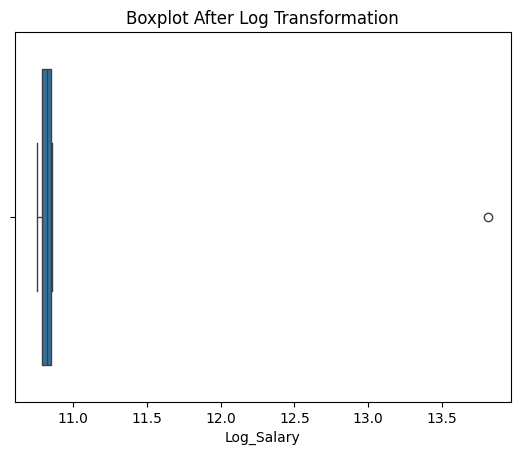

In [10]:

# Apply log transformation
df['Log_Salary'] = np.log(df['Salary'])

# Visualize after transformation
sns.boxplot(x=df['Log_Salary'])
plt.title("Boxplot After Log Transformation")
plt.show()




**✅ Best For:** Right-skewed data (e.g., income, sales).

---

### ⚡ **3.4 Imputation (Replacing Outliers):**  
Replace outliers with the mean, median, or mode

In [11]:

# Replace outliers with median
median_salary = df['Salary'].median()
df['Salary_Imputed'] = np.where(
    (df['Salary'] < lower_bound) | (df['Salary'] > upper_bound),
    median_salary,
    df['Salary']
)
print(df[['Salary', 'Salary_Imputed']])


     Salary  Salary_Imputed
0     50000         50000.0
1     52000         52000.0
2     48000         48000.0
3     51000         51000.0
4     49000         49000.0
5     47000         47000.0
6     50000         50000.0
7   1000000         50000.0
8     52000         52000.0
9     48000         48000.0
10    51000         51000.0



**✅ Best For:** When preserving dataset size is essential.

---

## 🤖 **4. Outlier Detection Using ML Algorithms**  

### 🤔 **4.1 Isolation Forest (Unsupervised):**  
Efficient for **high-dimensional data**.

In [12]:

from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['Anomaly_IF'] = iso_forest.fit_predict(df[['Salary', 'Age']])

# -1 indicates an anomaly
print(df[df['Anomaly_IF'] == -1])


   Age   Salary  Salary_Zscore  Salary_Winsorized  Log_Salary  Salary_Imputed  \
7  120  1000000       3.162224            1000000   13.815511         50000.0   

   Anomaly_IF  
7          -1  



---

### 🤔 **4.2 DBSCAN (Density-Based Clustering):**  
Groups similar data points and marks low-density points as outliers.

In [13]:

from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=10, min_samples=2)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df[['Age', 'Salary']])

# -1 indicates noise (outliers)
print(df[df['DBSCAN_Cluster'] == -1])


   Age   Salary  Salary_Zscore  Salary_Winsorized  Log_Salary  Salary_Imputed  \
4   28    49000      -0.319151              49000   10.799576         49000.0   
5   22    47000      -0.326473              47000   10.757903         47000.0   
7  120  1000000       3.162224            1000000   13.815511         50000.0   

   Anomaly_IF  DBSCAN_Cluster  
4           1              -1  
5           1              -1  
7          -1              -1  



---

### 🤔 **4.3 One-Class SVM (For Novelty Detection):**


In [14]:


from sklearn.svm import OneClassSVM

# Train One-Class SVM
svm = OneClassSVM(nu=0.1, kernel='rbf', gamma=0.1)
df['Anomaly_SVM'] = svm.fit_predict(df[['Salary', 'Age']])

# -1 indicates anomaly
print(df[df['Anomaly_SVM'] == -1])


    Age  Salary  Salary_Zscore  Salary_Winsorized  Log_Salary  Salary_Imputed  \
0    25   50000      -0.315490              50000   10.819778         50000.0   
1    30   52000      -0.308169              52000   10.858999         52000.0   
2    29   48000      -0.322812              48000   10.778956         48000.0   
3    35   51000      -0.311830              51000   10.839581         51000.0   
5    22   47000      -0.326473              47000   10.757903         47000.0   
6    26   50000      -0.315490              50000   10.819778         50000.0   
10   29   51000      -0.311830              51000   10.839581         51000.0   

    Anomaly_IF  DBSCAN_Cluster  Anomaly_SVM  
0            1               0           -1  
1            1               1           -1  
2            1               2           -1  
3            1               3           -1  
5            1              -1           -1  
6            1               0           -1  
10           1               


---

## ⚖️ **5. Choosing the Right Outlier Handling Technique**  

| **Scenario**                         | **Recommended Method**        |
|-------------------------------------|-------------------------------|
| Data entry error                    | **Remove outliers**  
| Extreme but valid values (e.g., income) | **Capping or Winsorization**  
| Skewed data                         | **Log/Box-Cox Transformation**  
| Anomaly detection in complex data   | **Isolation Forest, DBSCAN**  
| Time-series outliers                | **Rolling averages, EWMA**  



---

## 🏆 **6. Final Thoughts:**  

✔ **Outliers can distort ML models,** especially linear ones (e.g., Linear Regression).  
✔ **Robust models** like **Random Forest** or **XGBoost** handle outliers better than linear models.  
✔ **Always visualize data** before and after handling outliers to validate results.  
✔ Use **domain knowledge** to determine whether an outlier is a valid anomaly or an error.

💡 **Pro Tip:** Sometimes, **outliers are the insights!** (e.g., fraud detection, system failures).

---

## ***`Further Practice`***

### **`Z-Score Method`**


---

- **Z-Score** Manually

---


In [15]:
# Step 1: Import the required libraries
import pandas as pd
import numpy as np

# Step 2: Create the data
data = pd.DataFrame({'Age': [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 50]})

In [16]:
# Step 3: Calculate the mean and standard deviation
mean = np.mean(data['Age'])
std = np.std(data['Age'])

In [17]:
# Step 4: Calculate the Z-Score
data['Z-Score'] = (data['Age'] - mean) / std

In [18]:
# Step 5: Print the data
print("----------------------------------------")
print(f"Here is the data with outliers:\n {data}")
print("----------------------------------------")

----------------------------------------
Here is the data with outliers:
     Age   Z-Score
0    20 -0.938954
1    21 -0.806396
2    22 -0.673838
3    23 -0.541280
4    24 -0.408721
5    25 -0.276163
6    26 -0.143605
7    27 -0.011047
8    28  0.121512
9    29  0.254070
10   30  0.386628
11   50  3.037793
----------------------------------------


In [19]:
# Step 6: Print the outliers
print(f"Here are the outliers based on the z-score threshold, 3:\n {data[data['Z-Score'] > 3]}")
print("----------------------------------------")

Here are the outliers based on the z-score threshold, 3:
     Age   Z-Score
11   50  3.037793
----------------------------------------


In [20]:
# Step 7: Remove the outliers
data = data[data['Z-Score'] <= 3]

In [21]:
# Step 8: Print the data without outliers
print(f"Here is the data without outliers:\n {data}")

Here is the data without outliers:
     Age   Z-Score
0    20 -0.938954
1    21 -0.806396
2    22 -0.673838
3    23 -0.541280
4    24 -0.408721
5    25 -0.276163
6    26 -0.143605
7    27 -0.011047
8    28  0.121512
9    29  0.254070
10   30  0.386628


---

- **Z-Score** using ***scipy***.

---

In [22]:
# Import libraries
import numpy as np
from scipy import stats

# Sample data
data = [2.5, 2.7, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 110.0]

In [23]:
# Calculate the Z-score for each data point
z_scores = np.abs(stats.zscore(data))
z_scores

array([0.35584227, 0.34959942, 0.346478  , 0.34023515, 0.3339923 ,
       0.32774946, 0.32150661, 0.31526376, 0.30902092, 2.99968787])

In [24]:
# Set a threshold for identifying outliers
threshold = 2.5 
outliers = np.where(z_scores > threshold)[0]

In [25]:
# print the data
print("----------------------------------------")
print("Data:", data)
print("----------------------------------------")

print("Indices of Outliers:", outliers)
print("Outliers:", [data[i] for i in outliers])


----------------------------------------
Data: [2.5, 2.7, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 110.0]
----------------------------------------
Indices of Outliers: [9]
Outliers: [110.0]


In [26]:
# Remove outliers
data = [data[i] for i in range(len(data)) if i not in outliers]
print("----------------------------------------")
print("Data without outliers:", data)

----------------------------------------
Data without outliers: [2.5, 2.7, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0]


### ***`IQR Method`***

In [27]:
# Step 1: Import the required libraries
import pandas as pd
import numpy as np

# Step 2: Create the data
data = pd.DataFrame({'Age': [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 50]})

In [30]:
# Step 3: Calculate the first and third quartile
Q1 = np.percentile(data['Age'], 25, interpolation = 'midpoint')
Q3 = np.percentile(data['Age'], 75, interpolation = 'midpoint')

print(f"Q1: {Q1}")
print("-"*10)
print(f"Q3: {Q3}")

Q1: 22.5
----------
Q3: 28.5


In [31]:
# Step 4: Calculate the IQR
IQR = Q3 - Q1
print(f"IQR: {IQR}")

IQR: 6.0


In [32]:
# Step 5: Calculate the lower and upper bound
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"lower_bound: {lower_bound}")
print(f"upper_bound: {upper_bound}")

lower_bound: 13.5
upper_bound: 37.5


In [33]:
# Step 6: Print the data
print("----------------------------------------")
print(f"Here is the data with outliers:\n {data}")
print("----------------------------------------")

----------------------------------------
Here is the data with outliers:
     Age
0    20
1    21
2    22
3    23
4    24
5    25
6    26
7    27
8    28
9    29
10   30
11   50
----------------------------------------


In [34]:
# Step 7: Print the outliers
print(f"Here are the outliers based on the IQR threshold:\n {data[(data['Age'] < lower_bound) | (data['Age'] > upper_bound)]}")
print("----------------------------------------")

Here are the outliers based on the IQR threshold:
     Age
11   50
----------------------------------------


In [35]:
# Step 8: Remove the outliers
data = data[(data['Age'] >= lower_bound) & (data['Age'] <= upper_bound)]

In [36]:
# Step 9: Print the data without outliers
print(f"Here is the data without outliers:\n {data}")

Here is the data without outliers:
     Age
0    20
1    21
2    22
3    23
4    24
5    25
6    26
7    27
8    28
9    29
10   30


### ***`Clustering Method (K-Means)`***

In [37]:
# Import library
from sklearn.cluster import KMeans

# Sample data
data = [[2, 2], [3, 3], [3, 4], [30, 30], [31, 31], [32, 32]]

In [38]:
# Create a K-means model with two clusters (normal and outlier)
kmeans = KMeans(n_clusters=2, n_init=10)
kmeans.fit(data)

KMeans(n_clusters=2, n_init=10)

In [39]:
# Predict cluster labels
labels = kmeans.predict(data)

# Identify outliers based on cluster labels
outliers = [data[i] for i, label in enumerate(labels) if label == 1]

# print data
print("Data:", data)
print("Outliers:", outliers)

Data: [[2, 2], [3, 3], [3, 4], [30, 30], [31, 31], [32, 32]]
Outliers: [[2, 2], [3, 3], [3, 4]]


In [40]:
# Remove outliers
data = [data[i] for i, label in enumerate(labels) if label == 0]
print("Data without outliers:", data)

Data without outliers: [[30, 30], [31, 31], [32, 32]]


---